# 09. CVAE + Perceptual Loss — TensorFlow

기존 CVAE(`checkpoints_cvae_tf/`) 가중치를 불러온 뒤 VGG16 perceptual loss로 파인튜닝합니다.  
새 체크포인트는 `checkpoints_cvae_pl_tf/`에 별도 저장해 기존 모델을 덮어쓰지 않습니다.

| 손실 | 기존 CVAE | Perceptual CVAE |
|------|-----------|----------------|
| Reconstruction | MSE (픽셀 단위) | MSE + λ × VGG 피처 MSE |
| KL | β × KL | β × KL (동일) |

## 1. 환경 설정

In [11]:
import os, json, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, BatchNormalization,
    LeakyReLU, ReLU, Flatten, Dense, Reshape, Activation
)
from sklearn.model_selection import train_test_split

_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
DEVICE = '/GPU:0' if gpus else '/CPU:0'
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: /GPU:0


## 2. CFG

In [12]:
BASE_CKPT_DIR = Path('checkpoints_cvae_tf')    # 기존 CVAE 가중치 로드
PL_CKPT_DIR   = Path('checkpoints_cvae_pl_tf') # 파인튜닝 결과 저장
PL_CKPT_DIR.mkdir(exist_ok=True)

with open(BASE_CKPT_DIR / 'config.json') as f:
    BASE_CFG = json.load(f)

ACTIONS     = ['walk', 'idle', 'run', 'slash', 'shoot', 'thrust', 'jump', 'sit', 'spellcast']
LABEL_NAMES = ACTIONS + ['other']

CFG = {
    'latent_dim'   : BASE_CFG['latent_dim'],
    'base_channels': BASE_CFG['base_channels'],
    'channels'     : BASE_CFG['channels'],
    'num_classes'  : BASE_CFG['num_classes'],
    'epochs'       : 50,
    'batch_size'   : 128,
    'lr'           : 1e-4,      # 기존 1e-3보다 낮게
    'beta'         : BASE_CFG['beta'],
    'lambda_perc'  : 0.1,      # perceptual loss 가중치
    'patience'     : 10,
}

with open(PL_CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

LATENT_DIM   = CFG['latent_dim']
BASE_CH      = CFG['base_channels']
CHANNELS     = CFG['channels']
NUM_CLASSES  = CFG['num_classes']
EPOCHS       = CFG['epochs']
BATCH_SIZE   = CFG['batch_size']
LR           = CFG['lr']
BETA         = CFG['beta']
LAMBDA_PERC  = CFG['lambda_perc']
PATIENCE     = CFG['patience']
print('CFG:', CFG)

CFG: {'latent_dim': 128, 'base_channels': 32, 'channels': 4, 'num_classes': 10, 'epochs': 50, 'batch_size': 128, 'lr': 0.0001, 'beta': 1.0, 'lambda_perc': 0.1, 'patience': 10}


## 3. 데이터셋

In [13]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

def get_label(path):
    name = Path(path).name
    for i, kw in enumerate(ACTIONS):
        if kw in name: return i
    return len(ACTIONS)

labels    = [get_label(p) for p in all_paths]
str_paths = [str(p) for p in all_paths]

tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    str_paths, labels, test_size=0.1, random_state=42, stratify=labels
)
print(f'Train: {len(tr_paths)}  Val: {len(vl_paths)}')


def load_item(path, label):
    img = tf.image.decode_png(tf.io.read_file(path), channels=4)
    img = tf.cast(img, tf.float32) / 255.0
    c   = tf.one_hot(label, NUM_CLASSES)
    return img, c


def make_ds(paths, lbls, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    ds = ds.map(load_item, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_ds(tr_paths, tr_labels, shuffle=True)
val_ds   = make_ds(vl_paths, vl_labels)
print(f'Train batches: {len(train_ds)}  Val batches: {len(val_ds)}')

Train: 4089  Val: 455
Train batches: 32  Val batches: 4


## 4. CVAE 모델 정의

In [14]:
class CVAEEncoder(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128):
        super().__init__()
        self.conv_block = tf.keras.Sequential([
            Conv2D(base_ch,   4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*2, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*4, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*8, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Flatten(),
        ])
        self.fc_mu = Dense(latent_dim)
        self.fc_lv = Dense(latent_dim)

    def call(self, x, c, training=False):
        h = self.conv_block(x, training=training)
        h = tf.concat([h, c], axis=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        start_ch = base_ch * 8
        self.fc = Dense(start_ch * 4 * 4)
        self.deconv_block = tf.keras.Sequential([
            Reshape((4, 4, start_ch)),
            Conv2DTranspose(base_ch*4, 4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(base_ch*2, 4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(base_ch,   4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(channels,  4, 2, padding='same'), Activation('sigmoid'),
        ])

    def call(self, z, c, training=False):
        h = self.fc(tf.concat([z, c], axis=-1))
        return self.deconv_block(h, training=training)


class CVAE(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def reparameterize(self, mu, lv):
        return mu + tf.random.normal(tf.shape(mu)) * tf.exp(0.5 * lv)

    def call(self, x, c, training=False):
        mu, lv = self.encoder(x, c, training=training)
        z      = self.reparameterize(mu, lv)
        return self.decoder(z, c, training=training), mu, lv


with tf.device(DEVICE):
    model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS)

dummy_x = tf.zeros((1, 64, 64, CHANNELS))
dummy_c = tf.zeros((1, NUM_CLASSES))
_ = model(dummy_x, dummy_c)
print('Model built.')

Model built.


## 5. 기존 CVAE 가중치 로드

In [15]:
model.load_weights(str(BASE_CKPT_DIR / 'best.weights.h5'))
print(f'Loaded base CVAE weights from {BASE_CKPT_DIR}/best.weights.h5')
print(f'Base CFG: beta={BASE_CFG["beta"]}, epochs={BASE_CFG["epochs"]}')

Loaded base CVAE weights from checkpoints_cvae_tf/best.weights.h5
Base CFG: beta=1.0, epochs=100


## 6. Perceptual Loss (VGG16)

VGG16의 `relu1_2`, `relu2_2` 피처를 사용합니다.  
64×64 입력에서는 얕은 레이어 피처가 더 유의미하며, 깊은 레이어는 수용 범위가 입력을 초과할 수 있습니다.

RGBA → RGB: `rgb × α + 1 × (1 - α)` (흰 배경 합성)

In [16]:
vgg_base = tf.keras.applications.VGG16(
    include_top=False, weights='imagenet', input_shape=(64, 64, 3)
)
vgg_base.trainable = False

# relu1_2 = layer index 3, relu2_2 = layer index 8
feat_extractor = tf.keras.Model(
    inputs=vgg_base.input,
    outputs=[vgg_base.layers[3].output, vgg_base.layers[8].output]
)
feat_extractor.trainable = False

# VGG 전처리: [0,1] RGBA → white composite RGB → [0,255] BGR mean-subtract
def to_vgg(img_rgba):
    rgb   = img_rgba[..., :3]
    alpha = img_rgba[..., 3:4]
    rgb   = rgb * alpha + (1.0 - alpha)       # white background
    rgb   = rgb * 255.0
    return tf.keras.applications.vgg16.preprocess_input(rgb)


def perceptual_loss(real, fake):
    r_feats = feat_extractor(to_vgg(real),  training=False)
    f_feats = feat_extractor(to_vgg(fake),  training=False)
    loss = 0.0
    for rf, ff in zip(r_feats, f_feats):
        loss += tf.reduce_mean(tf.square(rf - ff))
    return loss


print('VGG16 feature extractor ready.')
print('  relu1_2:', vgg_base.layers[3].name)
print('  relu2_2:', vgg_base.layers[8].name)

VGG16 feature extractor ready.
  relu1_2: block1_pool
  relu2_2: block3_conv2


## 7. 파인튜닝

In [17]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)


def cosine_lr(epoch, total, base_lr, min_lr=1e-6):
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * epoch / total))


@tf.function
def train_step(x, c):
    with tf.GradientTape() as tape:
        recon, mu, lv = model(x, c, training=True)
        batch      = tf.cast(tf.shape(x)[0], tf.float32)
        mse_loss   = tf.reduce_sum(tf.square(x - recon)) / batch
        perc_loss  = perceptual_loss(x, recon)
        kl_loss    = -0.5 * tf.reduce_sum(1.0 + lv - tf.square(mu) - tf.exp(lv)) / batch
        loss       = mse_loss + LAMBDA_PERC * perc_loss + BETA * kl_loss
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, mse_loss, perc_loss, kl_loss


@tf.function
def val_step(x, c):
    recon, mu, lv = model(x, c, training=False)
    batch      = tf.cast(tf.shape(x)[0], tf.float32)
    mse_loss   = tf.reduce_sum(tf.square(x - recon)) / batch
    perc_loss  = perceptual_loss(x, recon)
    kl_loss    = -0.5 * tf.reduce_sum(1.0 + lv - tf.square(mu) - tf.exp(lv)) / batch
    return mse_loss + LAMBDA_PERC * perc_loss + BETA * kl_loss, mse_loss, perc_loss, kl_loss


history = {'loss': [], 'val_loss': [], 'mse': [], 'perc': [], 'kl': []}
best_val, patience_cnt = float('inf'), 0

for epoch in range(EPOCHS):
    optimizer.learning_rate.assign(cosine_lr(epoch, EPOCHS, LR))

    tr_loss = tr_mse = tr_perc = tr_kl = 0.0
    for x, c in train_ds:
        l, m, p, k = train_step(x, c)
        tr_loss += l.numpy(); tr_mse += m.numpy(); tr_perc += p.numpy(); tr_kl += k.numpy()
    n = len(train_ds)
    tr_loss /= n; tr_mse /= n; tr_perc /= n; tr_kl /= n

    vl_loss = vl_mse = vl_perc = vl_kl = 0.0
    for x, c in val_ds:
        l, m, p, k = val_step(x, c)
        vl_loss += l.numpy(); vl_mse += m.numpy(); vl_perc += p.numpy(); vl_kl += k.numpy()
    mv = max(len(val_ds), 1)
    vl_loss /= mv; vl_mse /= mv; vl_perc /= mv; vl_kl /= mv

    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['mse'].append(tr_mse)
    history['perc'].append(tr_perc)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  mse={tr_mse:.2f}  perc={tr_perc:.2f}  kl={tr_kl:.2f}  '
          f'val={vl_loss:.2f}')

    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        model.save_weights(str(PL_CKPT_DIR / 'best.weights.h5'))
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_weights(str(PL_CKPT_DIR / 'best.weights.h5'))
print(f'\nBest val_loss: {best_val:.4f}')

2026-06-28 16:02:44.798618: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 16:02:47.381732: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   1/50  loss=5290.51  mse=51.17  perc=52289.36  kl=10.40  val=13795.78


2026-06-28 16:02:56.473456: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 16:02:57.002342: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   2/50  loss=2918.82  mse=31.06  perc=28637.30  kl=24.02  val=3090.48


2026-06-28 16:03:05.983442: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 16:03:06.515713: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-06-28 16:10:21.431085: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 16:10:21.957166: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  49/50  loss=1323.65  mse=29.42  perc=12043.42  kl=89.89  val=1655.98


2026-06-28 16:10:30.921994: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  50/50  loss=1317.29  mse=29.30  perc=11980.66  kl=89.93  val=1656.36

Best val_loss: 1655.9754


2026-06-28 16:10:31.426638: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 8. 학습 곡선

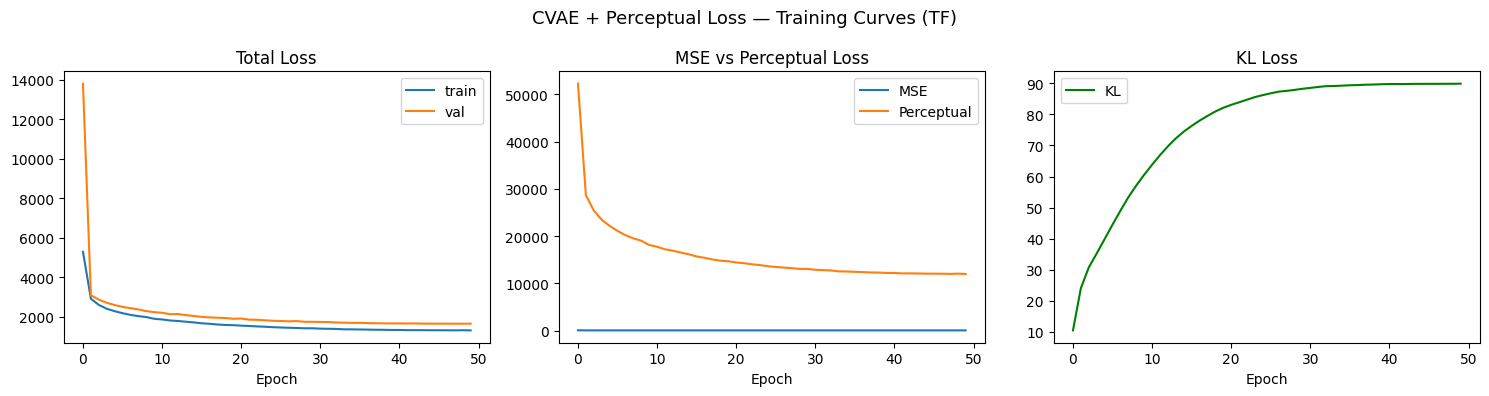

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'],     label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['mse'],  label='MSE')
axes[1].plot(history['perc'], label='Perceptual')
axes[1].set_title('MSE vs Perceptual Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['kl'], label='KL', color='green')
axes[2].set_title('KL Loss'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('CVAE + Perceptual Loss — Training Curves (TF)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. 복원 결과 비교 (Base CVAE vs Perceptual CVAE)

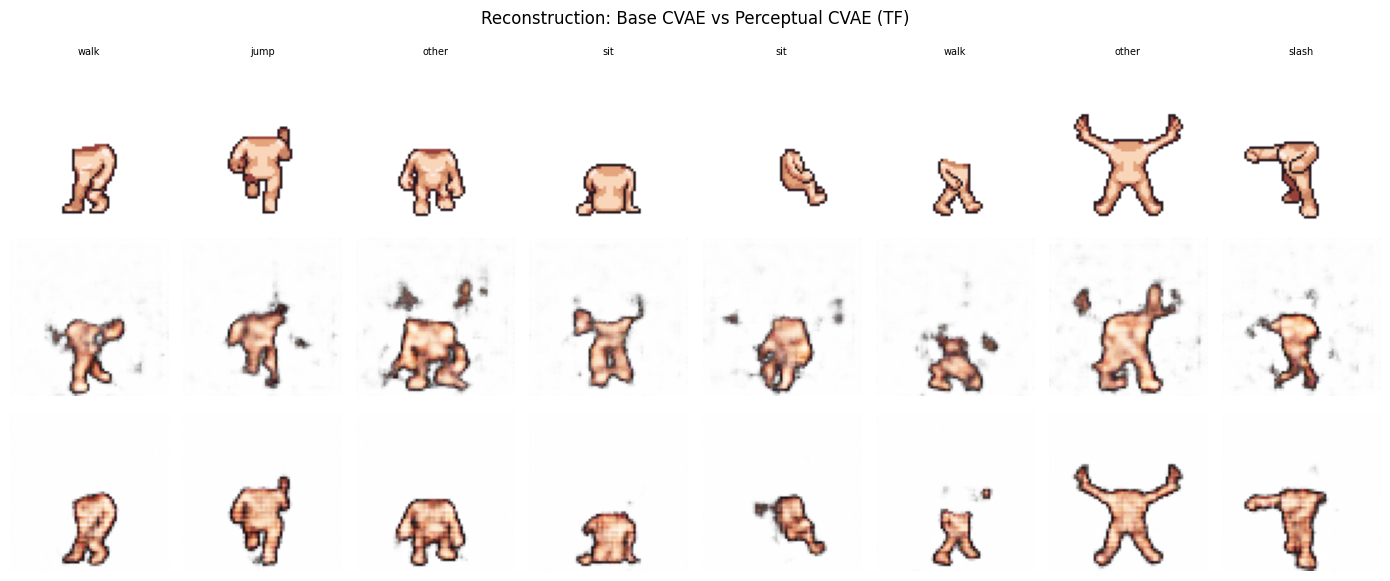

In [19]:
# 기존 CVAE 모델 (비교용)
base_model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS)
_ = base_model(dummy_x, dummy_c)
base_model.load_weights(str(BASE_CKPT_DIR / 'best.weights.h5'))


def composite(t):
    t = np.array(t)
    rgb, a = t[..., :3], t[..., 3:4]
    return np.clip(rgb * a + (1.0 - a), 0, 1)


sample_x, sample_c = next(iter(val_ds))
sample_x = sample_x[:8]
sample_c = sample_c[:8]

base_recon, _, _  = base_model(sample_x, sample_c, training=False)
pl_recon,   _, _  = model(sample_x, sample_c, training=False)

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
row_labels = ['Original', 'Base CVAE', 'Perceptual CVAE']
for i in range(8):
    lbl = tf.argmax(sample_c[i]).numpy()
    axes[0, i].imshow(composite(sample_x[i].numpy()))
    axes[0, i].set_title(LABEL_NAMES[lbl], fontsize=7)
    axes[1, i].imshow(composite(base_recon[i].numpy()))
    axes[2, i].imshow(composite(pl_recon[i].numpy()))
    for row in range(3):
        axes[row, i].axis('off')

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=9)

plt.suptitle('Reconstruction: Base CVAE vs Perceptual CVAE (TF)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. 조건부 생성 비교

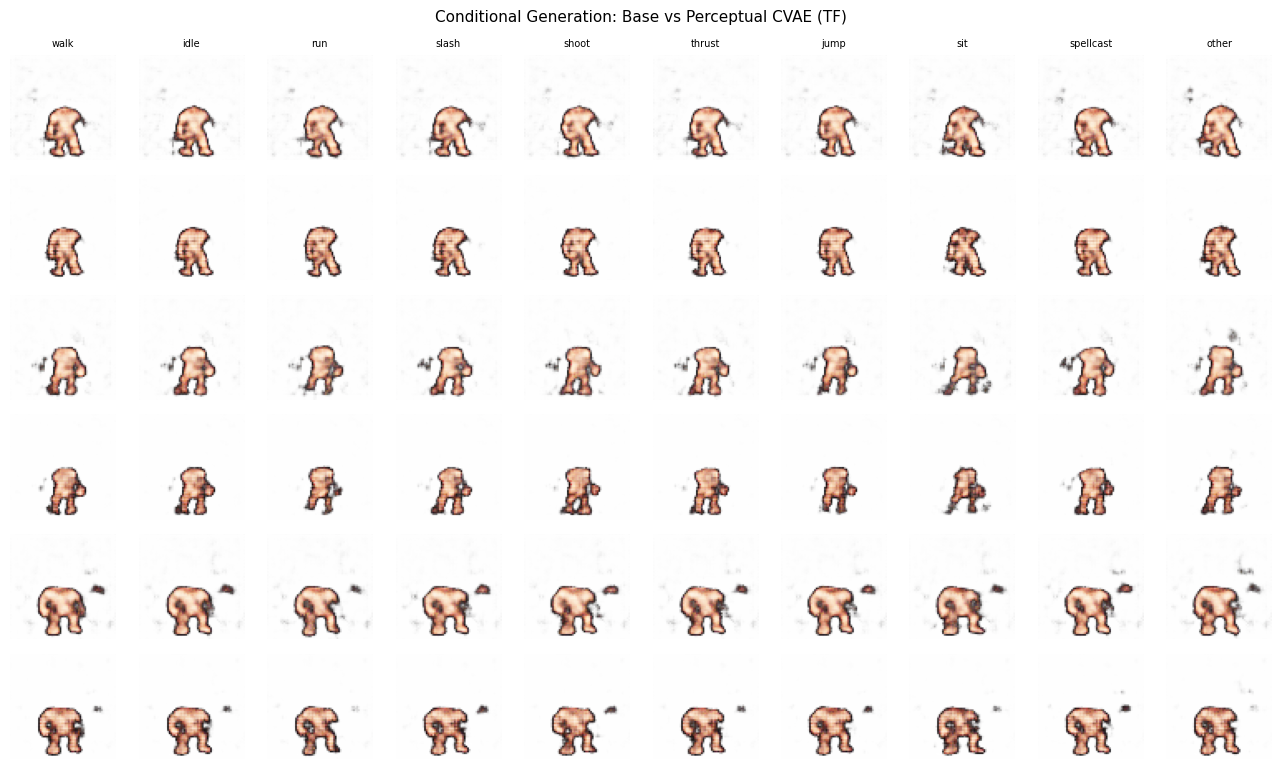

In [20]:
N_ROWS = 3
tf.random.set_seed(0)
z_samples = tf.random.normal((N_ROWS, LATENT_DIM))

fig, axes = plt.subplots(N_ROWS * 2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.3, N_ROWS * 2.6))

for row in range(N_ROWS):
    for col in range(NUM_CLASSES):
        c = tf.one_hot([col], NUM_CLASSES)
        z = tf.expand_dims(z_samples[row], 0)

        base_img = base_model.decoder(z, c, training=False)
        pl_img   = model.decoder(z, c, training=False)

        r0 = row * 2
        axes[r0,   col].imshow(composite(base_img[0].numpy()))
        axes[r0+1, col].imshow(composite(pl_img[0].numpy()))
        axes[r0,   col].axis('off')
        axes[r0+1, col].axis('off')
        if row == 0:
            axes[r0, col].set_title(LABEL_NAMES[col], fontsize=7)
    axes[row*2,   0].set_ylabel('Base', fontsize=8)
    axes[row*2+1, 0].set_ylabel('+ Perc', fontsize=8)

plt.suptitle('Conditional Generation: Base vs Perceptual CVAE (TF)', fontsize=11)
plt.tight_layout()
plt.show()